In [ ]:
from pathlib import Path

import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_DIR = Path(r"C:\Users\Fiorella\OneDrive\VSCODE PROJECTS\Projects\DTSC 2\Personal Project Part 1")
PROCESSED_DIR = PROJECT_DIR / "notebooks" / "data" / "processed"
OUTPUT_DIR = PROJECT_DIR / "notebooks" / "output"

analysis_file = PROCESSED_DIR / "charlotte_analysis.geojson"
gdf_analysis = gpd.read_file(analysis_file, engine="pyogrio")
gdf_analysis = gdf_analysis.to_crs(epsg=2264)

print(f"Loaded {len(gdf_analysis)} block groups")
print(f"Available columns: {list(gdf_analysis.columns)}")

Loaded 624 block groups
Available columns: ['GEOID_bg', 'canopy_pct_2022', 'canopy_pct_2018', 'canopy_change_pct', 'canopy_change_acres', 'impervious_pct', 'planting_opportunity_pct', 'GEOID_tract', 'total_population', 'median_income', 'mean_heat_index', 'mean_temp_f', 'heat_point_count', 'geometry']


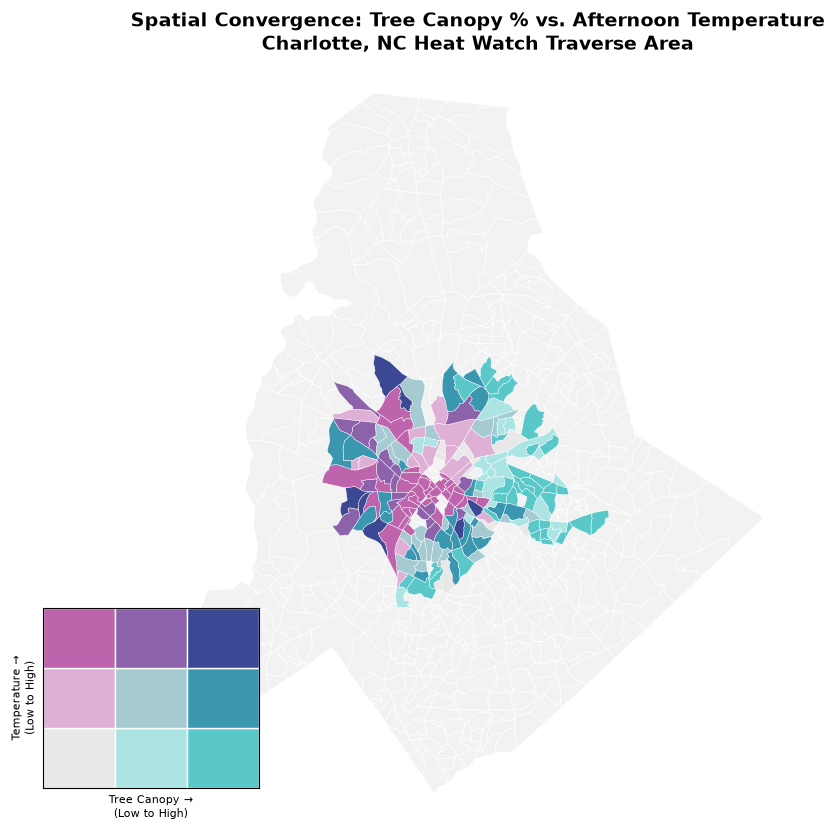

In [ ]:
# Classify heat-covered block groups by canopy and mean air temperature.
gdf_bivariate = gdf_analysis[gdf_analysis["mean_temp_f"].notna()].copy()
gdf_bivariate["canopy_tercile"] = pd.qcut(
    gdf_bivariate["canopy_pct_2022"], q=3, labels=[1, 2, 3]
).astype(int)
gdf_bivariate["temperature_tercile"] = pd.qcut(
    gdf_bivariate["mean_temp_f"], q=3, labels=[1, 2, 3]
).astype(int)
gdf_bivariate["bivariate_class"] = (
    gdf_bivariate["canopy_tercile"].astype(str)
    + "-"
    + gdf_bivariate["temperature_tercile"].astype(str)
)

bivariate_colors = {
    "1-1": "#e8e8e8", "1-2": "#dfb0d6", "1-3": "#be64ac",
    "2-1": "#ace4e4", "2-2": "#a5cad2", "2-3": "#8c62aa",
    "3-1": "#5ac8c8", "3-2": "#3b96b0", "3-3": "#3b4994",
}
gdf_bivariate["map_color"] = gdf_bivariate["bivariate_class"].map(bivariate_colors)

fig, ax = plt.subplots(figsize=(12, 10))
gdf_analysis.plot(ax=ax, color="#f2f2f2", edgecolor="#ffffff", linewidth=0.5)
gdf_bivariate.plot(
    ax=ax,
    color=gdf_bivariate["map_color"],
    edgecolor="#ffffff",
    linewidth=0.3,
)
ax.set_title(
    "Spatial Convergence: Tree Canopy % vs. Mean Air Temperature\n"
    "Charlotte, NC Heat Watch Traverse Area",
    fontsize=14,
    fontweight="bold",
)
ax.axis("off")

legend_ax = fig.add_axes([0.15, 0.15, 0.18, 0.18])
for canopy_level in range(1, 4):
    for temperature_level in range(1, 4):
        legend_ax.add_patch(
            mpatches.Rectangle(
                (canopy_level - 1, temperature_level - 1),
                1,
                1,
                color=bivariate_colors[f"{canopy_level}-{temperature_level}"],
                ec="white",
            )
        )
legend_ax.set_xlim(0, 3)
legend_ax.set_ylim(0, 3)
legend_ax.set_xlabel("Tree Canopy →\n(Low to High)", fontsize=8)
legend_ax.set_ylabel("Temperature →\n(Low to High)", fontsize=8)
legend_ax.set_xticks([])
legend_ax.set_yticks([])

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_DIR / "bivariate_choropleth_map.png", dpi=300, bbox_inches="tight")
plt.show()

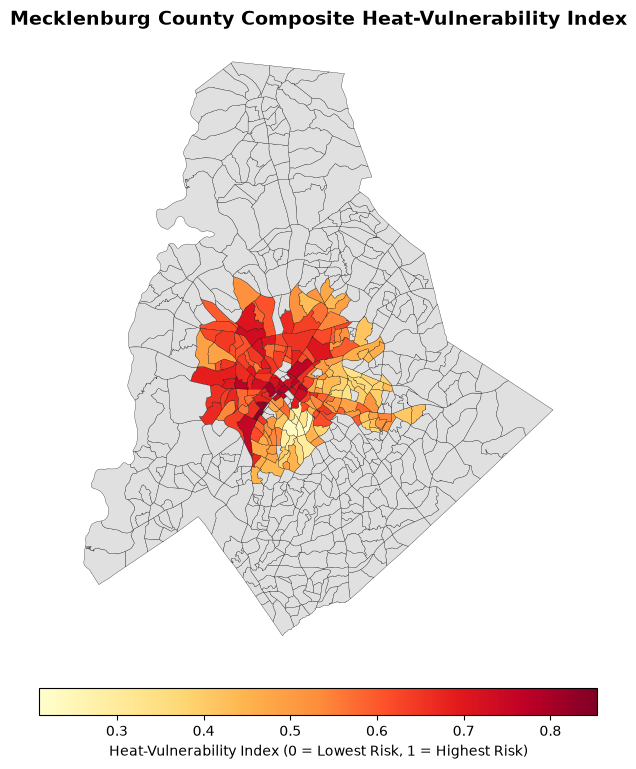

In [9]:
# Helper function for Min-Max Normalization (0 to 1 scaling)
def min_max_scale(series):
    return (series - series.min()) / (series.max() - series.min())


# Compute HVI for rows with complete heat, canopy, and income data.
hvi_df = gdf.dropna(
    subset=["mean_temp_f", "canopy_pct_2022", "median_income"]
).copy()

# 1. Normalize variables (0 = lowest risk, 1 = highest risk)
hvi_df["temp_score"] = min_max_scale(
    hvi_df["mean_temp_f"]
)  # Higher temperature = higher vulnerability
hvi_df["canopy_score"] = 1 - min_max_scale(
    hvi_df["canopy_pct_2022"]
)  # Lower canopy = higher vulnerability
hvi_df["income_score"] = 1 - min_max_scale(
    hvi_df["median_income"]
)  # Lower income = higher vulnerability

# 2. Composite score calculation
hvi_df["HVI_score"] = (
    hvi_df["temp_score"] + hvi_df["canopy_score"] + hvi_df["income_score"]
) / 3

# Align scores to the original GeoDataFrame; block groups without heat data stay missing.
gdf["HVI_score"] = hvi_df["HVI_score"]

# 3. Plot Composite HVI Map
fig, ax = plt.subplots(figsize=(12, 10))

gdf.plot(
    ax=ax,
    color="#e0e0e0",
    edgecolor="white",
    linewidth=0.5,
    label="No Heat Data",
)

gdf.plot(
    column="HVI_score",
    ax=ax,
    cmap="YlOrRd",
    legend=True,
    legend_kwds={
        "label": "Heat-Vulnerability Index (0 = Lowest Risk, 1 = Highest Risk)",
        "orientation": "horizontal",
        "pad": 0.03,
        "shrink": 0.6,
    },
    edgecolor="black",
    linewidth=0.2,
    missing_kwds={"color": "#e0e0e0", "label": "Outside Traverse Bounds"},
)

ax.set_title(
    "Mecklenburg County Composite Heat-Vulnerability Index",
    fontsize=14,
    fontweight="bold",
)
ax.axis("off")

output_dir = processed_file.parents[2] / "output"
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / "composite_hvi_map.png", dpi=300, bbox_inches="tight")
plt.show()

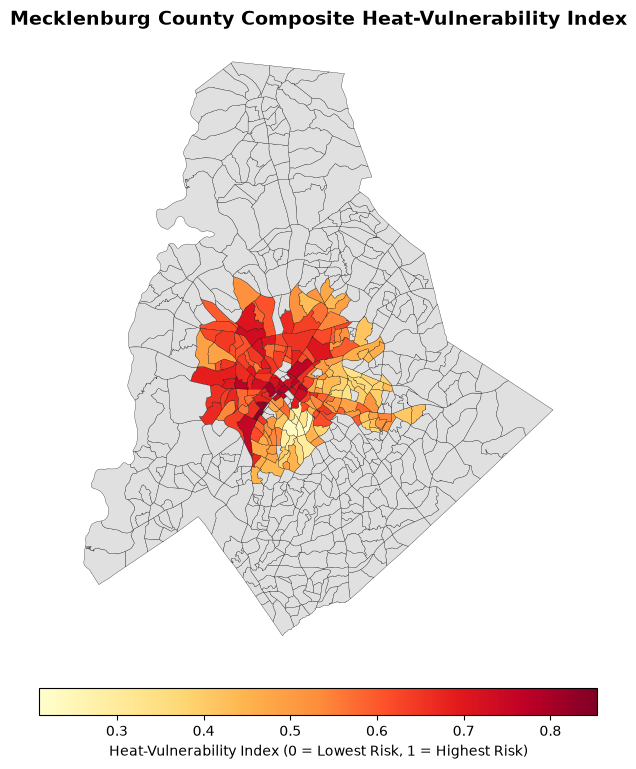

In [5]:
def min_max_scale(series):
    return (series - series.min()) / (series.max() - series.min())


# Build the index only where all three analysis measures are available.
hvi_df = gdf_analysis.dropna(
    subset=["mean_temp_f", "canopy_pct_2022", "median_income"]
).copy()
hvi_df["temperature_score"] = min_max_scale(hvi_df["mean_temp_f"])
hvi_df["canopy_score"] = 1 - min_max_scale(hvi_df["canopy_pct_2022"])
hvi_df["income_score"] = 1 - min_max_scale(hvi_df["median_income"])
hvi_df["hvi_score"] = hvi_df[
    ["temperature_score", "canopy_score", "income_score"]
].mean(axis=1)

gdf_analysis["hvi_score"] = hvi_df["hvi_score"]

fig, ax = plt.subplots(figsize=(12, 10))
gdf_analysis.plot(
    ax=ax,
    color="#e0e0e0",
    edgecolor="white",
    linewidth=0.5,
)
gdf_analysis.plot(
    column="hvi_score",
    ax=ax,
    cmap="YlOrRd",
    legend=True,
    legend_kwds={
        "label": "Heat-Vulnerability Index (0 = Lowest Risk, 1 = Highest Risk)",
        "orientation": "horizontal",
        "pad": 0.03,
        "shrink": 0.6,
    },
    edgecolor="black",
    linewidth=0.2,
    missing_kwds={"color": "#e0e0e0", "label": "Outside Traverse Bounds"},
)
ax.set_title(
    "Mecklenburg County Composite Heat-Vulnerability Index",
    fontsize=14,
    fontweight="bold",
)
ax.axis("off")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_DIR / "composite_hvi_map.png", dpi=300, bbox_inches="tight")
plt.show()

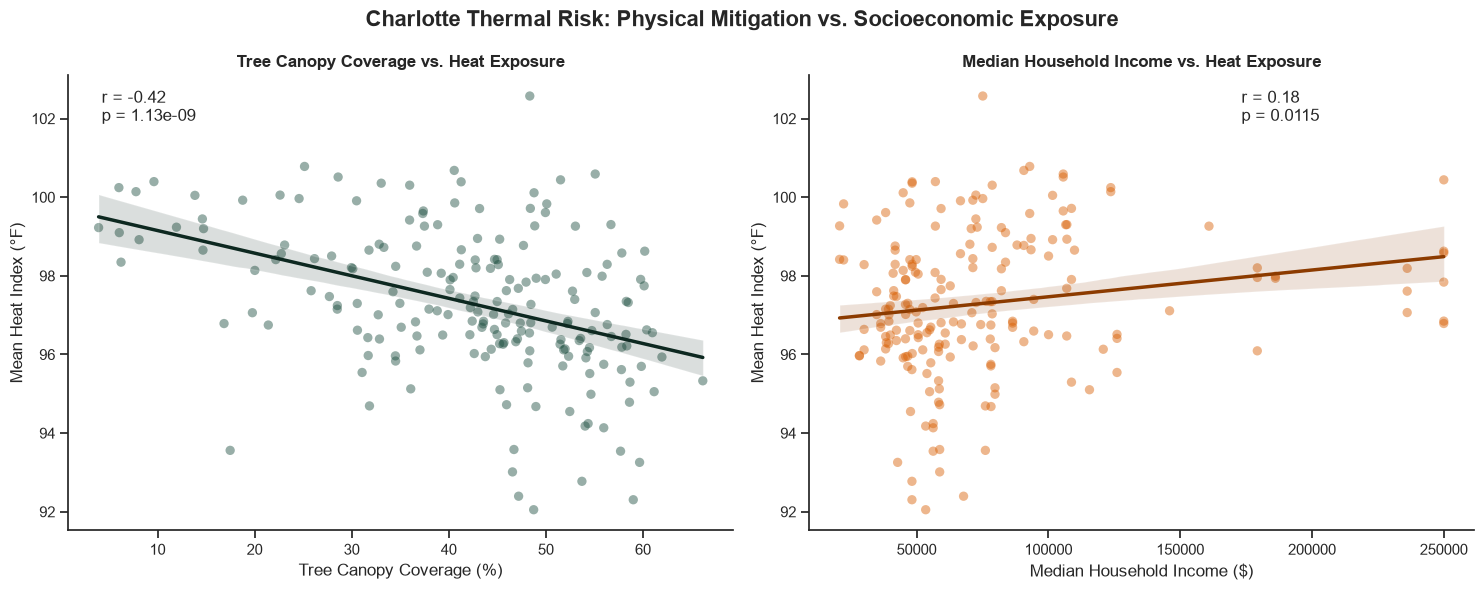

In [6]:
import seaborn as sns
from scipy import stats

sns.set_theme(style="ticks", font="sans-serif")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

canopy_heat = gdf_analysis.dropna(
    subset=["canopy_pct_2022", "mean_heat_index"]
)
sns.regplot(
    data=canopy_heat,
    x="canopy_pct_2022",
    y="mean_heat_index",
    ax=axes[0],
    color="#1b4d3e",
    scatter_kws={"alpha": 0.45, "s": 45, "edgecolor": "none"},
    line_kws={"color": "#0d2820", "linewidth": 2.5},
)
r1, p1 = stats.pearsonr(
    canopy_heat["canopy_pct_2022"], canopy_heat["mean_heat_index"]
)
axes[0].set_title("Tree Canopy Coverage vs. Heat Exposure", fontweight="bold")
axes[0].set_xlabel("Tree Canopy Coverage (%)")
axes[0].set_ylabel("Mean Heat Index (°F)")
axes[0].text(0.05, 0.90, f"r = {r1:.2f}\np = {p1:.3g}", transform=axes[0].transAxes)

income_heat = gdf_analysis.dropna(
    subset=["median_income", "mean_heat_index"]
)
sns.regplot(
    data=income_heat,
    x="median_income",
    y="mean_heat_index",
    ax=axes[1],
    color="#d95f02",
    scatter_kws={"alpha": 0.45, "s": 45, "edgecolor": "none"},
    line_kws={"color": "#8c3b00", "linewidth": 2.5},
)
r2, p2 = stats.pearsonr(
    income_heat["median_income"], income_heat["mean_heat_index"]
)
axes[1].set_title("Median Household Income vs. Heat Exposure", fontweight="bold")
axes[1].set_xlabel("Median Household Income ($)")
axes[1].set_ylabel("Mean Heat Index (°F)")
axes[1].text(0.65, 0.90, f"r = {r2:.2f}\np = {p2:.3g}", transform=axes[1].transAxes)

sns.despine()
plt.suptitle(
    "Charlotte Thermal Risk: Physical Mitigation vs. Socioeconomic Exposure",
    fontsize=16,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

In [ ]:
import folium

# Reproject the analysis dataset for an interactive web map.
gdf_map = gdf_analysis.to_crs(epsg=4326).copy()
gdf_map["income_label"] = gdf_map["median_income"].apply(
    lambda value: f"${value:,.0f}" if pd.notna(value) else "No data"
)
gdf_map["canopy_label"] = gdf_map["canopy_pct_2022"].apply(
    lambda value: f"{value:.1f}%" if pd.notna(value) else "No data"
)
gdf_map["heat_label"] = gdf_map["mean_heat_index"].apply(
    lambda value: f"{value:.1f} F" if pd.notna(value) else "Not sampled"
)

m = folium.Map(
    location=[35.2271, -80.8431],
    zoom_start=11,
    tiles="OpenStreetMap",
)

tooltip = folium.GeoJsonTooltip(
    fields=["GEOID_bg", "canopy_label", "income_label", "heat_label"],
    aliases=["Block group:", "Tree canopy:", "Median income:", "Mean heat index:"],
    localize=True,
    sticky=True,
)

folium.Choropleth(
    geo_data=gdf_map,
    name="Mean heat index",
    data=gdf_map,
    columns=["GEOID_bg", "mean_heat_index"],
    key_on="feature.properties.GEOID_bg",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Mean heat index (F)",
    nan_fill_color="#d9d9d9",
).add_to(m)

folium.GeoJson(
    gdf_map,
    name="Block groups",
    style_function=lambda feature: {
        "fillColor": "#00000000",
        "color": "#333333",
        "weight": 0.5,
    },
    tooltip=tooltip,
).add_to(m)
folium.LayerControl().add_to(m)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
map_file = OUTPUT_DIR / "charlotte_heat_equity_map.html"
m.save(map_file)
print(f"Saved interactive map to {map_file}")